In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using: {device}")

Using: cuda


In [3]:
BATCH_SIZE  = 128
NZ          = 100     # latent vector size
HIDDEN      = 256     # hidden layer size
IMAGE_DIM   = 28*28   # MNIST = 784
NUM_EPOCHS  = 5
LR          = 0.0002

In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # scale to [-1, 1]
])

dataset = torchvision.datasets.MNIST(
    root='./data', train=True, download=True, transform=transform
)
dataloader = torch.utils.data.DataLoader(
    dataset, batch_size=BATCH_SIZE, shuffle=True
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 19.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 484kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.37MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.19MB/s]


In [5]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            # z (100) → 256
            nn.Linear(NZ, HIDDEN),
            nn.LeakyReLU(0.2),

            # 256 → 512
            nn.Linear(HIDDEN, HIDDEN*2),
            nn.LeakyReLU(0.2),

            # 512 → 1024
            nn.Linear(HIDDEN*2, HIDDEN*4),
            nn.LeakyReLU(0.2),

            # 1024 → 784
            nn.Linear(HIDDEN*4, IMAGE_DIM),
            nn.Tanh()   # output in [-1, 1] to match normalised MNIST
        )

    def forward(self, z):
        return self.net(z)

Why LeakyReLU in D? Regular ReLU kills negative gradients, making the discriminator less informative. LeakyReLU(0.2) lets a small gradient flow through, keeping D from saturating.


Why Dropout in D? Prevents D from becoming too powerful too fast, which would starve G of useful gradients.



In [6]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            # 784 → 1024
            nn.Linear(IMAGE_DIM, HIDDEN*4),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            # 1024 → 512
            nn.Linear(HIDDEN*4, HIDDEN*2),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            # 512 → 256
            nn.Linear(HIDDEN*2, HIDDEN),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            # 256 → 1
            nn.Linear(HIDDEN, 1),
            nn.Sigmoid()   # probability: real or fake
        )

    def forward(self, x):
        return self.net(x)

In [7]:
G = Generator().to(device)
D = Discriminator().to(device)

criterion = nn.BCELoss()

opt_G = torch.optim.Adam(G.parameters(), lr=LR, betas=(0.5, 0.999))
opt_D = torch.optim.Adam(D.parameters(), lr=LR, betas=(0.5, 0.999))

# Fixed noise to visualise G's progress over epochs
fixed_z = torch.randn(64, NZ, device=device)

In [8]:
G_losses, D_losses = [], []

for epoch in range(NUM_EPOCHS):
    for real, _ in dataloader:
        b = real.size(0)

        # Flatten: (B, 1, 28, 28) → (B, 784)
        real = real.view(b, -1).to(device)

        real_labels = torch.ones(b, 1, device=device)
        fake_labels = torch.zeros(b, 1, device=device)

        # ── Train Discriminator ──────────────────────────
        D.zero_grad()

        out_real    = D(real)
        loss_D_real = criterion(out_real, real_labels)

        z           = torch.randn(b, NZ, device=device)
        fake        = G(z).detach()      # detach: don't backprop into G here
        out_fake    = D(fake)
        loss_D_fake = criterion(out_fake, fake_labels)

        loss_D = loss_D_real + loss_D_fake
        loss_D.backward()
        opt_D.step()

        # ── Train Generator ──────────────────────────────
        G.zero_grad()

        z      = torch.randn(b, NZ, device=device)
        fake   = G(z)
        out_g  = D(fake)
        # G wants D to think its outputs are real → label = 1
        loss_G = criterion(out_g, real_labels)
        loss_G.backward()
        opt_G.step()

        G_losses.append(loss_G.item())
        D_losses.append(loss_D.item())

    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}]  "
          f"Loss_D: {loss_D.item():.4f}  Loss_G: {loss_G.item():.4f}")

Epoch [1/5]  Loss_D: 0.3497  Loss_G: 2.9135
Epoch [2/5]  Loss_D: 1.2442  Loss_G: 0.7932
Epoch [3/5]  Loss_D: 0.9554  Loss_G: 1.1847
Epoch [4/5]  Loss_D: 0.2223  Loss_G: 3.5704
Epoch [5/5]  Loss_D: 0.2475  Loss_G: 3.5454


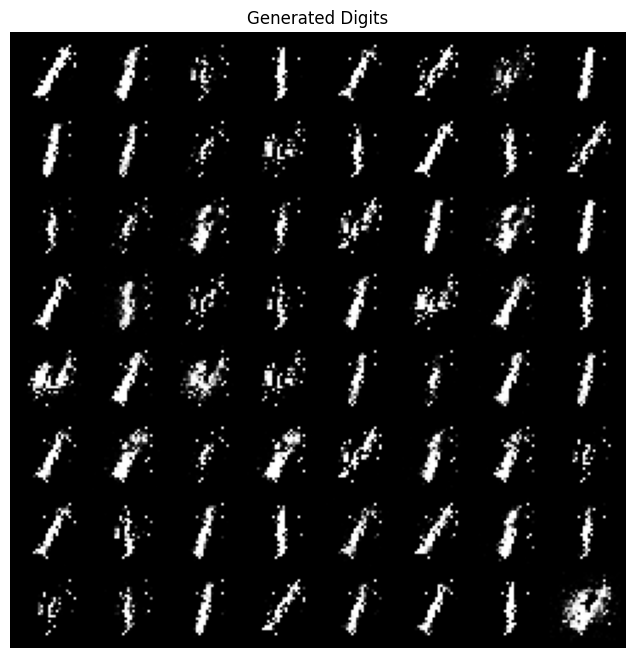

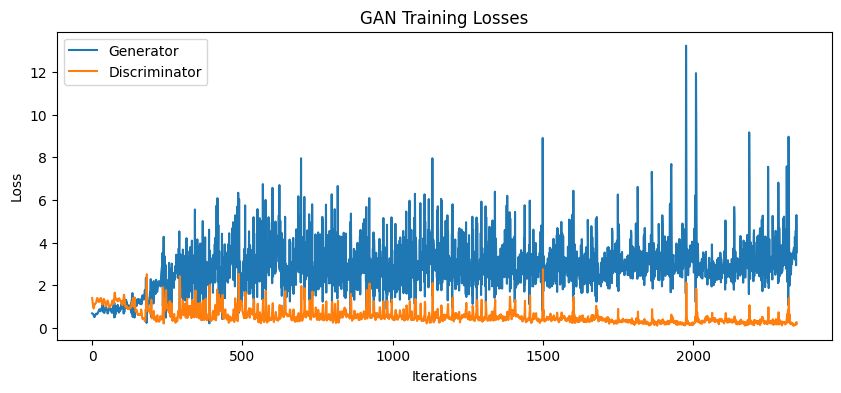

In [9]:
def show_generated(epoch=None):
    G.eval()
    with torch.no_grad():
        fake = G(fixed_z).view(-1, 1, 28, 28).cpu()
    G.train()

    grid = torchvision.utils.make_grid(fake, normalize=True, nrow=8)
    plt.figure(figsize=(8, 8))
    plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap='gray')
    plt.axis('off')
    plt.title(f"Epoch {epoch}" if epoch else "Generated Digits")
    plt.show()

# Call after training
show_generated()

# Loss curves
plt.figure(figsize=(10, 4))
plt.plot(G_losses, label='Generator')
plt.plot(D_losses, label='Discriminator')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.legend()
plt.title('GAN Training Losses')
plt.show()